In [1]:

import nest_asyncio
nest_asyncio.apply()  # 중첩 이벤트 루프 허용
import os
import json
import logging
import asyncio
import pandas as pd
import numpy as np
import openai
from datetime import datetime
import sys
from typing import List, Dict, Optional
# from tenacity import retry, stop_after_attempt, wait_exponential
import re
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
api = pd.read_csv('../../data/info.csv')
api_key = api.loc[1][1]


/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_83436/2384654932.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  api_key = api.loc[1][1]


In [2]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_colwidth', None)


In [3]:
sens = pd.read_parquet('/Users/nam-yeong/git/prj_centum/gpt_word/final_result/final_result_20250410_060315.parquet')
nums = pd.read_parquet('../../data/centum_data_numeric_cleaned.parquet')

sens['날짜'] = pd.to_datetime(sens['날짜'])
df = pd.merge(nums, sens, on=['환자번호','날짜'], how='left')

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
df = pd.merge(nums, sens, on=['환자번호','날짜'], how='left')
cols = [
       '환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI',
       'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_duration',
       '약_medication_type', '약_frequency', '약_duration', '약_compliance',
       '장치_device_type', '장치_usage_pattern', '장치_duration', '장치_compliance',
       '습관_habit_type', '습관_frequency', '습관_awareness', '습관_improvement',
       '찜질_status', '찜질_frequency', '찜질_duration', '찜질_method',
       '마사지, 스트레칭_type', '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration',
       '마사지, 스트레칭_method',
       'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity', 'oj', 'ob', 'Midline_Shift_Jaw',
       'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
       'Midline_Shift_Amount', 'CRCO_Direction_x', 'CRCO_Direction_y',
       'CRCO_Amount', 'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity', 'Rt_before', 'Rt_after',
       'Lt_before', 'Lt_after', 'Next_Visit_Days'
]
df = df[cols]

# df.to_parquet(f'../../data/final_without_pi_centum_data_with_medical_data_{timestamp}.parquet')

# df = pd.read_parquet('../../data/final_without_pi_centum_data_with_medical_data_20250411_225729.parquet')
del sens, nums
gc.collect()

0

### 데이터 전처리

In [4]:
## NaN 처리 

df = df.replace('', np.nan)
df = df.replace('-', np.nan)
df = df.replace('- -', np.nan)
df = df.replace('n/s', np.nan)

df['약_medication_type'] = df['약_medication_type'].replace('없음',np.nan)
df['약_medication_type'] = df['약_medication_type'].replace('약','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('약물 종류','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('약물 종류','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다복용함','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다복용','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('저녁약','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다양한 약물','약물 종류 미상')

df['Noise_Code'] = df['Noise_Code'].apply(lambda x : "No-Noise" if x == 0 else "Click" if x == 1 else "Popping" if x == 2 else "Crepitus" if x == 3 else "Unknown")

text_cols = [
    'CC_location','CC_pain_type','CC_painUncomp_desc_jaw','CC_disable_desc_jaw','CC_muscle_joint_desc_stress',
    'CC_dentalHistory_desc','CC_clinic_history_desc','CC_factor_habbit','CC_treat_plan',
    '약_medication_type','약_compliance','장치_device_type','습관_habit_type','습관_awareness'
    ]
numeric_cols = [
    'CC_duration','CC_severity', 'CC_vas', 'CMO_before','CMO_after','MMO_before','MMO_after','Midline_Shift_Amount','CRCO_Amount','Next_Visit_Days'
    ,'Rt_before','Rt_after','Lt_before','Lt_after','Tongue_ridging_Intensity','Mucosal_ridging_Intensity' ,'장치_duration','찜질_duration','마사지, 스트레칭_duration','약_duration'
    ,'M.pal_Pain_Intensity','Cap.pal_Pain_Intensity','Noise_Intensity','Occlusion_lt_Intensity','Occlusion_rt_Intensity', 'oj','ob'
    ]
category_cols = [
    '장치_usage_pattern','장치_compliance', '습관_frequency', '습관_improvement','약_frequency',
    '찜질_status','찜질_frequency', '마사지, 스트레칭_frequency','마사지, 스트레칭_method' ,'deviation_pattern_type','deviation_direction',
    'Cap.pal_Pain_Direction','Cap.pal_Pain_Situation','M.pal_Pain_Direction','M.pal_Pain_Situation','Noise_Code','Noise_Direction',
    'Noise_Situation','Occlusion_lt_number','Occlusion_rt_number','Midline_Shift_Jaw','Midline_Shift_Direction_x','Midline_Shift_Direction_y',
    'CRCO_Direction_x','CRCO_Direction_y','Cap.pal_Pain_Intensity','deviation_intensity',
    '마사지, 스트레칭_frequency','마사지, 스트레칭_type','찜질_method'
    ]


In [5]:
def extract_vas_values(df, source_col='CC', target_col='CC_vas'):
    """
    통합된 VAS 추출 및 처리 함수 - 수동 보정 포함
    """
    # 결과 컬럼 초기화
    df[target_col] = np.nan
    
    # 1. 정규식 패턴 정의 - 다양한 VAS 표현 형식 포괄
    vas_patterns = [
        r'(?i)vas\D*(\d+(?:\.\d+)?)',  # 기본 VAS 패턴
        r'(?i)통증점수\D*(\d+(?:\.\d+)?)',  # '통증점수' 포함 패턴
        r'(?i)통증 점수\D*(\d+(?:\.\d+)?)',  # '통증 점수' 포함 패턴
        r'(?i)통증강도\D*(\d+(?:\.\d+)?)',   # '통증강도' 포함 패턴
        r'(?i)점수[는은이가]\D*(\d+(?:\.\d+)?)'  # '점수는/은/이/가' 포함 패턴
    ]
    
    # 2. 'vas' 포함 행 필터링 (성능 최적화)
    mask = df[source_col].str.contains('|'.join(['vas', 'VAS', '통증점수', '통증 점수', '통증강도']), 
                                      na=False, regex=True)
    filtered = df.loc[mask, source_col]
    
    # 3. 모든 패턴에 대해 VAS 값 추출 시도
    extracted_values = pd.Series([None] * len(filtered), index=filtered.index)
    
    for pattern in vas_patterns:
        # 아직 값이 추출되지 않은 행에 대해서만 처리
        null_mask = extracted_values.isna()
        if not null_mask.any():
            break
            
        # 패턴 적용 시도
        try:
            pattern_result = filtered[null_mask].str.extract(pattern, expand=False)
            extracted_values.loc[null_mask] = pattern_result.combine_first(extracted_values.loc[null_mask])
        except Exception as e:
            print(f"패턴 '{pattern}' 처리 중 오류 발생: {e}")
    
    # 4. 결과 값 정제 - 숫자로 변환 및 유효 범위 확인
    extracted_values = pd.to_numeric(extracted_values, errors='coerce')
    
    # VAS 범위는 일반적으로 0-10이므로, 범위를 벗어난 값 처리
    extracted_values = extracted_values.apply(
        lambda x: float(x) if pd.notna(x) and 0 <= float(x) <= 100 else np.nan
    )
    
    # 100 초과 값은 잘못 추출된 것으로 간주하고 범위 조정
    extracted_values = extracted_values.apply(
        lambda x: float(x)/10 if pd.notna(x) and 10 < float(x) <= 100 else x
    )
    
    # 5. 추출된 값 원본 데이터프레임에 적용
    df.loc[mask, target_col] = extracted_values
    
    # 6. 제공된 수동 보정 데이터 적용
    # 수동 보정 데이터
    manual_correction_data = {
        'index': [1409, 1815, 3576, 4372, 5344, 9603, 10634, 10767, 12041, 13048,
                  13081, 13218, 14292, 14615, 15034, 15576, 16569, 16730, 16925, 16967,
                  18848, 20403, 21441, 22723, 22804, 23610, 23669, 23815, 24390, 25705,
                  26581, 27379],
        'CC_vas': [3, 3, 7, 1, 1, 3, 8, 7, 2, 6,
                   2, 0, 5, 3, 2, 3, 1, 5, 3, 1,
                   3, 2, 10, 4, 4, 4, 2, 7, 5, 8,
                   0, 3]
    }
    
    # 수동 보정 데이터를 딕셔너리로 변환
    manual_corrections = dict(zip(manual_correction_data['index'], manual_correction_data['CC_vas']))
    
    # 수동 보정 값 적용
    for idx, val in manual_corrections.items():
        if idx in df.index:
            df.loc[idx, target_col] = val
            
    # 7. 데이터 유효성 검사 및 통계
    vas_stats = {
        '자동 추출된 VAS 값 수': mask.sum(),
        '수동 보정된 VAS 값 수': sum(idx in df.index for idx in manual_corrections.keys()),
        '최종 유효 VAS 값 수': df[target_col].notna().sum(),
        'VAS 값 범위': f"{df[target_col].min()} ~ {df[target_col].max()}" if df[target_col].notna().any() else "N/A"
    }
    print(f"VAS 값 추출 통계: {vas_stats}")
    
    return df

In [6]:
def handle_missing_values(df):
    """
    데이터 유형을 고려한 개선된 결측치 처리 함수
    """
    # 1. 범주형과 수치형 변수 구분 - 존재하는 열만 처리
    numeric_cols = [col for col in df.columns if col in [
        'CC_severity', 'CMO_before', 'MMO_before', 'dif_MMO_CMO'
    ] or col.endswith('_Intensity') or col.endswith('_duration')]
    
    # CC_vas가 있으면 포함
    if 'CC_vas' in df.columns:
        numeric_cols.append('CC_vas')
    
    categorical_cols = [col for col in df.columns if col not in numeric_cols 
                       and not pd.api.types.is_datetime64_any_dtype(df[col])
                       and col != '환자번호']
    
    # 2. 표준화된 결측값 변환
    for replace_val in ['', '-', '- -', 'n/s', '없음']:
        df = df.replace(replace_val, np.nan)
    
    # 3. 수치형 변수 형변환 및 결측치 처리
    for col in numeric_cols:
        # 먼저 숫자형으로 안전하게 변환
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception as e:
            print(f"컬럼 {col} 변환 중 오류 발생: {e}")
        
        # 동일 환자의 다른 방문 데이터가 있으면 그 값으로 대체
        df[col] = df.groupby('환자번호')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )
        
        # 여전히 결측치가 있는 경우 중앙값으로 대체
        try:
            median_val = df[col].median()
            if pd.notna(median_val):  # None이 아닌지 확인
                df[col] = df[col].fillna(median_val)
        except TypeError:
            # 중앙값을 계산할 수 없는 경우 0으로 대체
            print(f"컬럼 {col}의 중앙값을 계산할 수 없습니다. 0으로 대체합니다.")
            df[col] = df[col].fillna(0)
    
    # 4. 범주형 변수 결측치 처리
    for col in categorical_cols:
        # 중요도가 높은 열만 최빈값으로 대체, 나머지는 'Unknown'으로 대체
        if col in ['CC_location', 'CC_pain_type', 'Noise_Code', '습관_habit_type']:
            try:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown'
                df[col] = df[col].fillna(mode_val)
            except:
                df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna('Unknown')
            
    return df

In [7]:
# 일일 성장률 계산 함수 추가
def add_daily_growth_rate(df, column_name):
    """
    원본 데이터프레임에 일일 성장률 피처를 추가하는 함수
    
    Parameters:
    df (DataFrame): 환자 데이터가 포함된 데이터프레임
    column_name (str): 성장률을 계산할 컬럼명
    
    Returns:
    DataFrame: 일일 성장률 피처가 추가된 데이터프레임
    """
    # 날짜 형식 변환 (이미 변환되어 있지 않은 경우)
    if not pd.api.types.is_datetime64_any_dtype(df['날짜']):
        df['날짜'] = pd.to_datetime(df['날짜'])
    
    # 환자별로 그룹화하여 처리
    df_copy = df.copy()
    
    # 환자별, 날짜별로 정렬
    df_copy = df_copy.sort_values(['환자번호', '날짜'])
    
    # 환자별 첫 방문 값 추출
    first_values = df_copy.groupby('환자번호')[column_name].first().reset_index()
    first_values.columns = ['환자번호', f'첫방문_{column_name}']
    
    # 첫 방문 값을 원본 데이터에 병합
    df_copy = pd.merge(df_copy, first_values, on='환자번호', how='left')
    
    # 일일 성장률 계산 (첫 방문 대비)
    df_copy[f'{column_name}_일일성장률'] = 0.0
    
    # 문자열 데이터 타입 확인 및 숫자로 변환
    numeric_mask = pd.to_numeric(df_copy[column_name], errors='coerce').notna() & pd.to_numeric(df_copy[f'첫방문_{column_name}'], errors='coerce').notna()
    
    # 숫자로 변환 가능한 데이터만 처리
    if numeric_mask.any():
        # 숫자형으로 변환
        current_values = pd.to_numeric(df_copy.loc[numeric_mask, column_name])
        first_visit_values = pd.to_numeric(df_copy.loc[numeric_mask, f'첫방문_{column_name}'])
        
        # 0으로 나누기 방지
        valid_mask = (first_visit_values != 0)
        
        # 유효한 데이터에 대해서만 성장률 계산
        if valid_mask.any():
            df_copy.loc[numeric_mask[numeric_mask].index[valid_mask], f'{column_name}_일일성장률'] = (
                (current_values[valid_mask] - first_visit_values[valid_mask]) / 
                first_visit_values[valid_mask] * 100
            )
    
    return df_copy

# # 각 지표별 일일 성장률 피처 추가
# for column in ['CMO_before', 'CC_vas', 'MMO_before','dif_MMO_CMO', 'Cap.pal_Pain_Intensity', 
#                'M.pal_Pain_Intensity', 'Occlusion_lt_number', 'Occlusion_rt_number', 
#                'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity', 
#                'Rt_before', 'Rt_after', 'Lt_before', 'Lt_after']:
#     try:
#         df = add_daily_growth_rate(df, column)
#     except Exception as e:
#         print(f"{column} 처리 중 오류 발생: {e}")
# # 컬럼 중 "첫방문"이 들어간 텍스트 추출
# # 컬럼 중 "첫방문"이 들어간 컬럼 제거
# first_visit_columns = [col for col in df.columns if '첫방문' in col]
# df = df.drop(columns=first_visit_columns)

In [8]:
def preprocessing_pipeline(df):
    """
    데이터 전처리 통합 파이프라인 - 데이터 타입 처리 강화
    """
    print("1. 데이터 로딩 완료, 행 수:", len(df))
    
    # 1. 기본 결측치 변환 (문자열 -> NaN)
    for replace_val in ['', '-', '- -', 'n/s', '없음']:
        df = df.replace(replace_val, np.nan)
    print("2. 기본 결측치 변환 완료")
    
    # 2. 수치형 열 미리 변환
    numeric_candidates = ['CMO_before', 'MMO_before', 'CC_severity', 'CC_vas']
    for col in numeric_candidates:
        if col in df.columns:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                print(f"컬럼 {col} 숫자형 변환 완료")
            except Exception as e:
                print(f"컬럼 {col} 변환 실패: {e}")
    
    # 3. VAS 값 추출 및 정제
    df = extract_vas_values(df)
    print("3. VAS 값 추출 완료")
    
    # 4. 고급 결측치 처리
    df = handle_missing_values(df)
    print("4. 고급 결측치 처리 완료")
    
    # 5. MMO-CMO 차이 계산
    if 'MMO_before' in df.columns and 'CMO_before' in df.columns:
        # 계산 전 다시 한번 숫자형 확인
        df['MMO_before'] = pd.to_numeric(df['MMO_before'], errors='coerce')
        df['CMO_before'] = pd.to_numeric(df['CMO_before'], errors='coerce')
        df['dif_MMO_CMO'] = df['MMO_before'] - df['CMO_before']
        print("5. MMO-CMO 차이 계산 완료")
    
    # 6. 성장률 계산
    growth_columns = ['CMO_before', 'CC_vas', 'MMO_before', 'dif_MMO_CMO']
    for column in growth_columns:
        if column in df.columns:
            try:
                df = add_daily_growth_rate(df, column)
                print(f"컬럼 {column} 성장률 계산 완료")
            except Exception as e:
                print(f"컬럼 {column} 성장률 계산 실패: {e}")
    
    # 7. 오류 데이터 필터링
    if 'dif_MMO_CMO' in df.columns:
        # 깊은 복사로 경고 방지
        orig_len = len(df)
        df = df.query('dif_MMO_CMO >= 0').copy()
        print(f"7. 오류 데이터 필터링: {orig_len - len(df)}개 행 제거됨, 남은 행 수: {len(df)}")
    
    return df

In [9]:
df = preprocessing_pipeline(df)

1. 데이터 로딩 완료, 행 수: 28162
2. 기본 결측치 변환 완료
컬럼 CMO_before 숫자형 변환 완료
컬럼 MMO_before 숫자형 변환 완료
컬럼 CC_severity 숫자형 변환 완료
VAS 값 추출 통계: {'자동 추출된 VAS 값 수': 14108, '수동 보정된 VAS 값 수': 32, '최종 유효 VAS 값 수': 14101, 'VAS 값 범위': '0.0 ~ 10.0'}
3. VAS 값 추출 완료


/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_83436/147469774.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_83436/147469774.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_83436/147469774.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out

4. 고급 결측치 처리 완료
5. MMO-CMO 차이 계산 완료
컬럼 CMO_before 성장률 계산 완료
컬럼 CC_vas 성장률 계산 완료
컬럼 MMO_before 성장률 계산 완료
컬럼 dif_MMO_CMO 성장률 계산 완료
7. 오류 데이터 필터링: 262개 행 제거됨, 남은 행 수: 27900


### 피처 생성
y값 기준 정의
- vas 처음 대비 20% 미만으로 감소한 환자, 
- cmo 43mm 이상으로 증가한 환자, 
- mmo-cmo 차이가 0이 된 환자 등

- after 의 경우 Null 값이 너무 많음. drop (내판단)

In [10]:
# 환자 데이터 추적을 위한 함수 정의
def extract_patient_progress(df, column_name):
    """ 
    환자별 첫 방문과 마지막 방문의 특정 컬럼 값을 추출하는 함수
    
    Parameters:
    df (DataFrame): 환자 데이터가 포함된 데이터프레임
    column_name (str): 추적할 컬럼명 (예: 'CMO_before', 'CC_vas', 'MMO_before')
    
    Returns:
    DataFrame: 환자별 첫 방문과 마지막 방문의 해당 컬럼 값이 포함된 데이터프레임
    """
    # 날짜 형식 변환 (이미 변환되어 있지 않은 경우)
    if not pd.api.types.is_datetime64_any_dtype(df['날짜']):
        df['날짜'] = pd.to_datetime(df['날짜'])
    
    # 환자별 첫 방문일과 마지막 방문일 데이터 추출
    first_visit = df.sort_values('날짜').groupby('환자번호').first().reset_index()[['환자번호', '날짜', column_name]]
    last_visit = df.sort_values('날짜').groupby('환자번호').last().reset_index()[['환자번호', '날짜', column_name]]
    
    # 열 이름 변경
    first_visit.columns = ['환자번호', '첫방문일', f'첫방문_{column_name}']
    last_visit.columns = ['환자번호', '마지막방문일', f'마지막방문_{column_name}']
    
    # 두 데이터프레임 병합
    patient_progress = pd.merge(first_visit, last_visit, on='환자번호')
    patient_progress[f'마지막방문_{column_name}'] = patient_progress[f'마지막방문_{column_name}'].astype(float)
    patient_progress[f'첫방문_{column_name}'] = patient_progress[f'첫방문_{column_name}'].astype(float)
    # 차이 및 성장률 계산
    patient_progress[f'{column_name}_차이'] = patient_progress[f'마지막방문_{column_name}'] - patient_progress[f'첫방문_{column_name}']
    
    # 성장률 계산 (0으로 나누는 오류 방지)
    patient_progress[f'{column_name}_성장률'] = 0.0
    mask = patient_progress[f'첫방문_{column_name}'] != 0
    patient_progress.loc[mask, f'{column_name}_성장률'] = (
        (patient_progress.loc[mask, f'마지막방문_{column_name}'] - 
         patient_progress.loc[mask, f'첫방문_{column_name}']) / 
        patient_progress.loc[mask, f'첫방문_{column_name}'] * 100
    )
    
    # 계산된 컬럼만 반환 (마지막 방문 데이터 포함)
    return patient_progress[['환자번호',
                             f'첫방문_{column_name}', 
                             f'마지막방문_{column_name}', f'{column_name}_차이', f'{column_name}_성장률']]

# 각 지표별 환자 진행 상황 추출 및 차이/성장률 계산
progress_data = {}
for column in ['CMO_before', 'CC_vas', 'MMO_before','dif_MMO_CMO', 'Cap.pal_Pain_Intensity', 
               'M.pal_Pain_Intensity', 'Occlusion_lt_number', 'Occlusion_rt_number', 
               'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity', 
               'Rt_before', 'Rt_after', 'Lt_before', 'Lt_after']:
    progress_data[column] = extract_patient_progress(df, column)

# 모든 진행 데이터를 환자번호를 기준으로 병합
patient_progress = progress_data['CMO_before']
for column in list(progress_data.keys())[1:]:
    patient_progress = pd.merge(
        patient_progress, 
        progress_data[column], 
        on='환자번호', 
        how='left'
    )


ValueError: could not convert string to float: 'Unknown'

In [11]:
df.head()

,환자번호,날짜,CC,약,장치,습관,찜질,"마사지, 스트레칭",PI,CMO,MMO,Cap.pal,M.pal,Noise,Loading,Occlusion,OJ/OB,Class,Midline Shift,Deviation,CR-CO,Tongue ridging,Mucosal ridging,Ultrasono,Rt,Lt,치료계획,End feel,CC_location,CC_pain_type,CC_painUncomp_desc_jaw,CC_disable_desc_jaw,CC_muscle_joint_desc_stress,CC_dentalHistory_desc,CC_clinic_history_desc,CC_factor_habbit,CC_treat_plan,CC_severity,CC_duration,약_medication_type,약_frequency,약_duration,약_compliance,장치_device_type,장치_usage_pattern,장치_duration,장치_compliance,습관_habit_type,습관_frequency,습관_awareness,습관_improvement,찜질_status,찜질_frequency,찜질_duration,찜질_method,"마사지, 스트레칭_type","마사지, 스트레칭_frequency","마사지, 스트레칭_duration","마사지, 스트레칭_method",CMO_before,CMO_after,MMO_before,MMO_after,deviation_pattern_type,deviation_direction,deviation_intensity,Cap.pal_Pain_Intensity,Cap.pal_Pain_Direction,Cap.pal_Pain_Situation,M.pal_Pain_Intensity,M.pal_Pain_Direction,M.pal_Pain_Situation,Noise_Code,Noise_Direction,Noise_Intensity,Noise_Situation,Occlusion_lt_number,Occlusion_rt_number,Occlusion_lt_Intensity,Occlusion_rt_Intensity,oj,ob,Midline_Shift_Jaw,Midline_Shift_Direction_x,Midline_Shift_Direction_y,Midline_Shift_Amount,CRCO_Direction_x,CRCO_Direction_y,CRCO_Amount,Tongue_ridging_Intensity,Mucosal_ridging_Intensity,Rt_before,Rt_after,Lt_before,Lt_after,Next_Visit_Days,CC_vas,dif_MMO_CMO,첫방문_CMO_before,CMO_before_일일성장률,첫방문_CC_vas,CC_vas_일일성장률,첫방문_MMO_before,MMO_before_일일성장률,첫방문_dif_MMO_CMO,dif_MMO_CMO_일일성장률
0,2111-04,2021-11-11,"일주일 정도 전부터 턱이 잘 안 벌어지고 소리가 나면서 걸린 적이 두 번 정도 있었어요.항생제 알러지(이름은모른다고하심)12345678 12345678Dr.남윤진료파노라마 - K07.65 턱관절의 퇴행성관절염- 파노라마내역턱관절염 통증 호소하여 파노라마 촬영함12345678 12345678Dr.남윤진료파노라마 특수 촬영 - K07.65 턱관절의 퇴행성관절염- 파노라마(특수)파노라마(특수) 턱관절 질환으로 통증 호소하여 과두, 관절와 확인위해 측두하악관절규격촬영 시행12345678 12345678Dr.남윤진료CT 촬영 - K07.65 턱관절의 퇴행성관절염- Cone Beam CT판독소견 flattening on Rt TMJ sclerotic change on Lt TMJ- Conclusion : 턱관절의 퇴행성 관절염 (K07.65)내역퇴행성 관절염으로 CT촬영함12345678 12345678Dr.남윤진료측두하악장애분석검사 - K07.65 턱관절의 퇴행성관절염- 측두하악장애분석검사측두하악장애분석검사 측두하악장애분석검사 진행- 세크로정(아세클로페낙) - 1/2회/3일",Unknown,Unknown,Unknown,Unknown,Unknown,Bite(Rt/Lt) : 4567/4567,27mm,40mm (턱이 빠질까봐 크게 벌리지 못함),Unknown,"Both (+), Both tenderpoint (Rt > Lt )",Lt click,Unknown,Unknown,2/2,),Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,-> 0.73-1.26,-> 0.76-1.27,Unknown,soft,왼쪽 턱,통증,"턱 통증, 악관절에서 소리 남","제한된 개구, 턱 관절 움직임 제한","치아 악물기, 근육 긴장",Unknown,Unknown,Unknown,Unknown,3.0,10.0,Unknown,Unknown,NaN,Unknown,Unknown,Unknown,2.0,Unknown,치아 접촉 줄이기,Unknown,Unknown,Unknown,Unknown,Unknown,10.0,Unknown,Unknown,Unknown,10.0,Unknown,27.0,Unknown,40.0,Unknown,other,unspecified,normal,0,unspecified,Unknown,0,both,Unknown,Click,left,0,Unknown,0,0,0,0,2.0,2.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,0,Unknown,0.73,Unknown,0.73,Unknown,3.0,13.0,27.0,0.000000,3.0,0.0,40.0,0.0,13.0,0.000000
1,2111-04,2021-11-25,"1주일 ckPt:찜질은 한적 없고, 입을 크게 벌리려고 안했어요. 식사할때 왼쪽에서 뚜둑뚜둑 걸리는 느낌이 들었어요크게 벌리지 않으려고 의식 하다보니 아프지는 않았는데 질긴거 먹을때 왼쪽 턱에서 소리가 났어요. 약 복용한건 속 안쓰리고 괜찮았어요.12345678 12345678Dr.남윤진료분사신장치료 - K07.66 저작근의 장애- 분사신장치료12345678 12345678Dr.남윤진료악관절 고착 해소술 - K07.60 턱관절내장증- 악관절고착해소술12345678 12345678Dr.남윤진료TMJ자극요법-전기 - K07.66 저작근의 장애- 측두하악관절자극요법-전기자극측두하악관절자극요법-전기자극 11월 3일에 측두하악장애 분석검사 시행12345678 12345678Dr.남윤진료TMJ자극요법-복합 - K07.66 저작근의 장애- 측두하악관절자극요법-복합자극측두하악관절자극요법-복합자극 11월 3일에 측두하악장애 분석검사 시행",Unknown,Unknown,Unknown,Unknown,Unknown,- cotton bite + spray and stretching + 고착해소술 후 opening 시 부드러워짐 온찜질 꼭 해달라고 권유드림. 질긴 음식 피해달라고 말씀 드리고 주의사항 설명드림.물리치료 [1주후],27mm (통증은 아니고 걸리는 느낌),44mm --> spray and stretch,Unknown,Lt) pain (Rt 적은 pain),cotton bite-- Lt) closing click (벌리고 나면 부드러워짐),Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,->,->,Unknown,soft,왼쪽 턱,뚜둑뚜둑 걸리는 느낌,턱에서 소리가 났어요,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,3.0,10.0,Unknown,Unknown,NaN,Unknown,Unknown,Unknown,2.0,Unknown,치아 접촉 줄이기,Unknown,Unknown,Unknown,Unknown,Unknown,10.0,Unknown,Unknown,Unknown,10.0,Unknown,27.0,Unknown,44.0,Unknown,other,unspecified,normal,0,unspecified,Unknown,0,both,Unknown,Cl

In [ ]:
def identify_recovered_patients(patient_progress):
    """
    개선된 타겟 환자 식별 함수 - 완치 기준에 따라 환자 식별
    """
    # 기준별로 함수 정의하여 모듈화
    def vas_improved(data, threshold=-20):
        """VAS 개선 기준 적용"""
        return data[data['CC_vas_성장률'] <= threshold]['환자번호']
    
    def cmo_improved(data, min_value=43, growth_check=True):
        """CMO 개선 기준 적용"""
        if growth_check:
            return data[(data['마지막방문_CMO_before'] >= min_value) & 
                        (data['CMO_before_성장률'] > 0)]['환자번호']
        else:
            return data[data['마지막방문_CMO_before'] >= min_value]['환자번호']
    
    def mmo_cmo_normalized(data):
        """MMO-CMO 간격 정상화 기준 적용"""
        return data[(data['마지막방문_dif_MMO_CMO'] == 0) & 
                   (data['dif_MMO_CMO_성장률'] < 0)]['환자번호']
    
    # 각 기준별 환자 식별
    recovered_by_criteria = {
        'vas_improved': vas_improved(patient_progress),
        'cmo_improved': cmo_improved(patient_progress),
        'mmo_cmo_normalized': mmo_cmo_normalized(patient_progress)
    }
    
    # 각 기준별 환자 수 통계
    criteria_stats = {k: len(v) for k, v in recovered_by_criteria.items()}
    print(f"기준별 완치 환자 통계: {criteria_stats}")
    
    # 모든 기준을 만족하는 환자
    fully_recovered = set(recovered_by_criteria['vas_improved']) & \
                     set(recovered_by_criteria['cmo_improved']) & \
                     set(recovered_by_criteria['mmo_cmo_normalized'])
    
    # 최소 하나의 기준을 만족하는 환자 (기존 로직과 동일)
    any_criteria_recovered = set(recovered_by_criteria['vas_improved']) | \
                            set(recovered_by_criteria['cmo_improved']) | \
                            set(recovered_by_criteria['mmo_cmo_normalized'])
    
    # 통계 정보
    recovery_stats = {
        '완전 완치(모든 기준 충족)': len(fully_recovered),
        '부분 완치(1개 이상 기준 충족)': len(any_criteria_recovered),
        '전체 환자': len(patient_progress)
    }
    print(f"완치 환자 통계: {recovery_stats}")
    
    # 완치 환자 목록 반환 (기존과 동일하게 하나 이상의 기준을 만족하는 환자)
    return list(any_criteria_recovered), recovery_stats, recovered_by_criteria

#### y값 기준 설정을 위한 성장률 분포

In [152]:
# 각 성장률 열에 대해 10% 단위로 환자 분포 확인
growth_columns = [
    'CMO_before_성장률','dif_MMO_CMO_성장률', 'CC_vas_성장률','MMO_before_성장률','Cap.pal_Pain_Intensity_성장률',
    'M.pal_Pain_Intensity_성장률','Occlusion_lt_number_성장률','Occlusion_rt_number_성장률',
    'Tongue_ridging_Intensity_성장률','Mucosal_ridging_Intensity_성장률','Rt_before_성장률',
    'Rt_after_성장률','Lt_before_성장률','Lt_after_성장률'
]

# 10% 단위로 구간 나누기
# 성장률 구간을 10% 단위로 설정
bins = list(range(-100, 101, 10))
bins.append(float('inf'))  # 100% 초과 구간 추가
labels = [f'{i}% ~ {i+10}%' for i in range(-100, 100, 10)]
labels.append('100% 초과')

# 각 열에 대해 구간별 환자 수 계산
growth_data = {}
for column in growth_columns:
    growth_data[column] = pd.cut(patient_progress[column], bins=bins, labels=labels).value_counts().sort_index()

# 피봇 테이블 형태로 변환
growth_pivot = pd.DataFrame(growth_data)
# 피봇 테이블 출력
print("성장률 구간별 환자 분포 피봇 테이블:")
display(growth_pivot)

성장률 구간별 환자 분포 피봇 테이블:


,CMO_before_성장률,dif_MMO_CMO_성장률,CC_vas_성장률,MMO_before_성장률,Cap.pal_Pain_Intensity_성장률,M.pal_Pain_Intensity_성장률,Occlusion_lt_number_성장률,Occlusion_rt_number_성장률,Tongue_ridging_Intensity_성장률,Mucosal_ridging_Intensity_성장률,Rt_before_성장률,Rt_after_성장률,Lt_before_성장률,Lt_after_성장률
-100% ~ -90%,0,35,16,0,0,0,0,0,0,0,1,0,1,0
-90% ~ -80%,0,95,148,0,0,0,2,2,0,0,0,0,0,0
-80% ~ -70%,0,98,123,0,0,0,2,3,0,0,0,0,0,0
-70% ~ -60%,0,116,252,1,1,14,2,2,0,0,0,0,0,0
-60% ~ -50%,3,122,233,0,0,2,11,7,4,2,0,1,0,1
-50% ~ -40%,2,63,112,1,0,0,0,0,0,0,5,2,5,2
-40% ~ -30%,5,68,147,9,0,0,3,2,0,0,6,8,6,8
-30% ~ -20%,23,65,140,14,0,0,4,4,0,0,25,31,25,31
-20% ~ -10%,52,24,67,74,0,0,3,3,0,0,23,28,23,28
-10% ~ 0%,2224,2662,2273,2559,4933,4689,4858,4875,4942,4940,4317,4382,4317,4382


In [178]:
growth_pivot[['CMO_before_성장률', 'dif_MMO_CMO_성장률', 'CC_vas_성장률']]

,CMO_before_성장률,dif_MMO_CMO_성장률,CC_vas_성장률
-100% ~ -90%,0,35,16
-90% ~ -80%,0,95,148
-80% ~ -70%,0,98,123
-70% ~ -60%,0,116,252
-60% ~ -50%,3,122,233
-50% ~ -40%,2,63,112
-40% ~ -30%,5,68,147
-30% ~ -20%,23,65,140
-20% ~ -10%,52,24,67
-10% ~ 0%,2224,2662,2273


In [182]:
df.환자번호.nunique(), len(tgt)

(4977, 2534)

/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_60249/2545036254.py:9: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_60249/2545036254.py:9: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_60249/2545036254.py:9: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_60249/2545036254.py:9: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_60249/2545036254.py:9: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from current font.
  plt.tight_layout()


<Figure size 1500x1000 with 0 Axes>

/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: Use

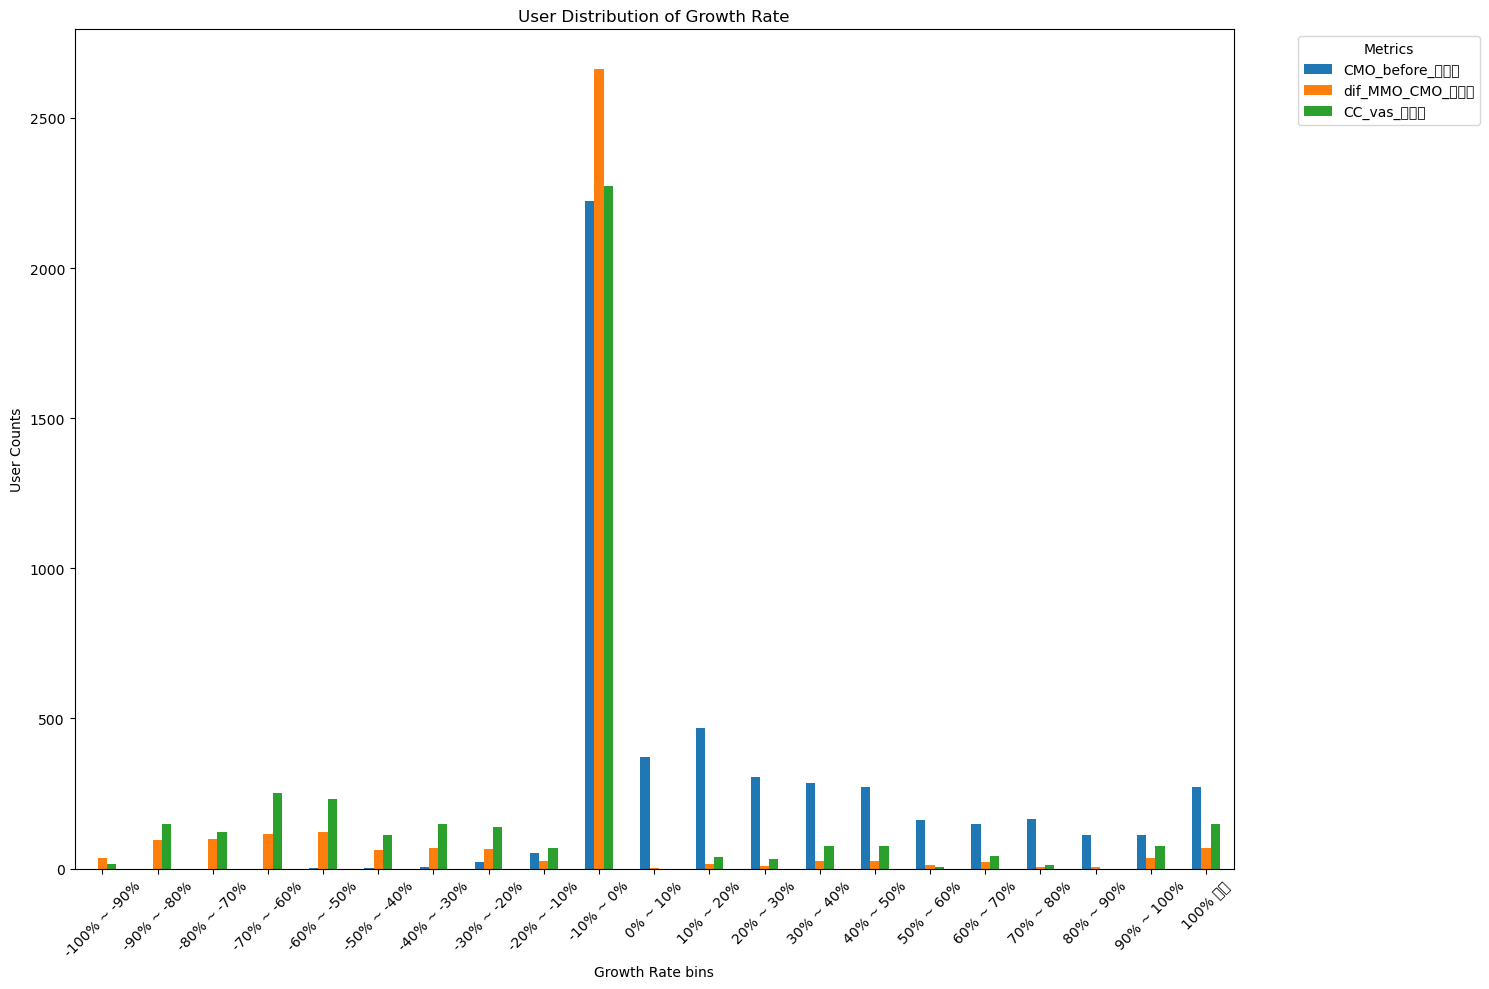

In [179]:
# 시각화 (선택적)
plt.figure(figsize=(15, 10))
growth_pivot[['CMO_before_성장률', 'dif_MMO_CMO_성장률', 'CC_vas_성장률']].plot(kind='bar', figsize=(15, 10))
plt.title('User Distribution of Growth Rate')
plt.xlabel('Growth Rate bins')
plt.ylabel('User Counts')
plt.xticks(rotation=45)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### 최종적으로 완치된 타겟들 도출

In [194]:
patient_progress[['첫방문_dif_MMO_CMO', '마지막방문_dif_MMO_CMO','dif_MMO_CMO_성장률','마지막방문_CMO_before']]

,첫방문_dif_MMO_CMO,마지막방문_dif_MMO_CMO,dif_MMO_CMO_성장률,마지막방문_CMO_before
0,13.0,10.0,-23.076923,38.0
1,15.0,12.0,-20.000000,40.0
2,4.0,3.0,-25.000000,40.0
3,11.0,19.0,72.727273,35.0
4,2.0,0.0,-100.000000,50.0
...,...,...,...,...
4972,5.0,5.0,0.000000,43.0
4973,28.0,28.0,0.000000,20.0
4974,14.0,14.0,0.000000,29.0
4975,22.0,22.0,0.000000,20.0


### 모델

#### 임베딩을 위한 맥락 부여

In [11]:
import pandas as pd
import openai
import numpy as np

def create_contextual_text(row):
    """
    환자 데이터를 임상적 맥락을 강화한 방식으로 구조화하여 텍스트 생성
    """
    # 안전하게 열 접근하는 헬퍼 함수
    def safe_access(row, key):
        if isinstance(row, dict):
            return row.get(key, None)
        else:
            try:
                return row[key] if key in row.index else None
            except:
                return None
    
    # 값 유효성 확인 헬퍼 함수
    def is_valid(value):
        return pd.notna(value) and value is not None
    
    # 최종 임상 텍스트를 담을 섹션별 컨테이너
    clinical_sections = []
    
    # 1. 주호소 및 증상 섹션 (Core Symptoms)
    symptoms_context = []
    
    # 증상 위치와 종류 통합
    cc_location = safe_access(row, 'CC_location')
    cc_pain_type = safe_access(row, 'CC_pain_type')
    
    if is_valid(cc_location) and is_valid(cc_pain_type):
        symptoms_context.append(f"주호소: 환자는 {cc_location}에 {cc_pain_type}을 호소합니다.")
    elif is_valid(cc_location):
        symptoms_context.append(f"주호소 위치: {cc_location}")
    elif is_valid(cc_pain_type):
        symptoms_context.append(f"통증 유형: {cc_pain_type}")
    
    # 턱 관련 통증과 불편감 세부 정보 추가
    cc_painUncomp_desc_jaw = safe_access(row, 'CC_painUncomp_desc_jaw')
    if is_valid(cc_painUncomp_desc_jaw):
        symptoms_context.append(f"턱 관련 통증 및 불편감: {cc_painUncomp_desc_jaw}")
    
    # 기능적 제한 정보 추가
    cc_disable_desc_jaw = safe_access(row, 'CC_disable_desc_jaw')
    if is_valid(cc_disable_desc_jaw):
        symptoms_context.append(f"턱 기능 제한: {cc_disable_desc_jaw}")
    
    
    # 근육과 관절 관련 증상 추가
    cc_muscle_joint_desc_stress = safe_access(row, 'CC_muscle_joint_desc_stress')
    if is_valid(cc_muscle_joint_desc_stress):
        symptoms_context.append(f"근육 및 관절 상태: {cc_muscle_joint_desc_stress}")
    
    # 통증 강도와 지속 기간 정보
    cc_severity = safe_access(row, 'CC_severity')
    if is_valid(cc_severity):
        symptoms_context.append(f"통증 강도(1-5): {cc_severity}")
    
    cc_vas = safe_access(row, 'CC_vas')
    if is_valid(cc_vas):
        symptoms_context.append(f"VAS 통증 점수: {cc_vas}")
    
    cc_duration = safe_access(row, 'CC_duration')
    if is_valid(cc_duration):
        symptoms_context.append(f"증상 지속 기간: {cc_duration}")
    
    # 증상 섹션을 통합하여 전체 맥락에 추가
    if symptoms_context:
        clinical_sections.append("【증상 정보】\n" + "\n".join(symptoms_context))
    
    # 2. 병력 및 습관 섹션 (History & Habits)
    history_context = []
    
    # 치과 관련 과거력
    cc_dentalHistory_desc = safe_access(row, 'CC_dentalHistory_desc')
    if is_valid(cc_dentalHistory_desc):
        history_context.append(f"치과 병력: {cc_dentalHistory_desc}")
    
    # 클리닉 방문 이력
    cc_clinic_history_desc = safe_access(row, 'CC_clinic_history_desc')
    if is_valid(cc_clinic_history_desc):
        history_context.append(f"턱관절 관련 과거 치료: {cc_clinic_history_desc}")
    
    # 생활 습관 요인
    cc_factor_habbit = safe_access(row, 'CC_factor_habbit')
    if is_valid(cc_factor_habbit):
        history_context.append(f"생활 습관 요인: {cc_factor_habbit}")
    
    # 습관 관련 상세 정보
    habit_details = []
    
    habit_type = safe_access(row, '습관_habit_type')
    if is_valid(habit_type):
        habit_details.append(f"습관 유형: {habit_type}")
    
    habit_frequency = safe_access(row, '습관_frequency')
    if is_valid(habit_frequency):
        habit_details.append(f"습관 빈도: {habit_frequency}")
    
    habit_awareness = safe_access(row, '습관_awareness')
    if is_valid(habit_awareness):
        habit_details.append(f"습관 인지 여부: {habit_awareness}")
    
    habit_improvement = safe_access(row, '습관_improvement')
    if is_valid(habit_improvement):
        habit_details.append(f"습관 개선 상태: {habit_improvement}")
    
    if habit_details:
        history_context.append("습관 상세정보: " + ", ".join(habit_details))
    
    # 병력 및 습관 섹션을 통합하여 전체 맥락에 추가
    if history_context:
        clinical_sections.append("【병력 및 습관】\n" + "\n".join(history_context))
    
    # 3. 치료 관련 섹션 (Treatment)
    treatment_context = []
    
    # 치료 계획
    cc_treat_plan = safe_access(row, 'CC_treat_plan')
    if is_valid(cc_treat_plan):
        treatment_context.append(f"치료 계획: {cc_treat_plan}")
    
    # 약물 관련 정보
    medication_details = []
    
    medication_type = safe_access(row, '약_medication_type')
    if is_valid(medication_type):
        medication_details.append(f"약물 유형: {medication_type}")
    
    medication_frequency = safe_access(row, '약_frequency')
    if is_valid(medication_frequency):
        medication_details.append(f"복용 빈도: {medication_frequency}")
    
    medication_duration = safe_access(row, '약_duration')
    if is_valid(medication_duration):
        medication_details.append(f"복용 기간: {medication_duration}")
    
    medication_compliance = safe_access(row, '약_compliance')
    if is_valid(medication_compliance):
        medication_details.append(f"복약 순응도: {medication_compliance}")
    
    if medication_details:
        treatment_context.append("약물 정보: " + ", ".join(medication_details))
    
    # 장치 관련 정보
    device_details = []
    
    device_type = safe_access(row, '장치_device_type')
    if is_valid(device_type):
        device_details.append(f"장치 유형: {device_type}")
    
    device_usage_pattern = safe_access(row, '장치_usage_pattern')
    if is_valid(device_usage_pattern):
        device_details.append(f"사용 패턴: {device_usage_pattern}")
    
    device_duration = safe_access(row, '장치_duration')
    if is_valid(device_duration):
        device_details.append(f"사용 기간: {device_duration}")
    
    device_compliance = safe_access(row, '장치_compliance')
    if is_valid(device_compliance):
        device_details.append(f"장치 순응도: {device_compliance}")
    
    if device_details:
        treatment_context.append("장치 정보: " + ", ".join(device_details))
    
    # 찜질/마사지 정보
    therapy_details = []
    
    # 찜질 정보
    hot_pack_info = []
    hot_pack_status = safe_access(row, '찜질_status')
    
    if is_valid(hot_pack_status) and hot_pack_status == 1:
        hot_pack_info.append("찜질 시행")
        
        hot_pack_frequency = safe_access(row, '찜질_frequency')
        if is_valid(hot_pack_frequency):
            hot_pack_info.append(f"빈도: {hot_pack_frequency}")
        
        hot_pack_duration = safe_access(row, '찜질_duration')
        if is_valid(hot_pack_duration):
            hot_pack_info.append(f"시간: {hot_pack_duration}분")
        
        hot_pack_method = safe_access(row, '찜질_method')
        if is_valid(hot_pack_method):
            hot_pack_info.append(f"방법: {hot_pack_method}")
    
    if hot_pack_info:
        therapy_details.append("찜질: " + ", ".join(hot_pack_info))
    
    # 마사지/스트레칭 정보
    massage_info = []
    
    massage_type = safe_access(row, '마사지, 스트레칭_type')
    if is_valid(massage_type):
        massage_info.append(f"유형: {massage_type}")
        
        massage_frequency = safe_access(row, '마사지, 스트레칭_frequency')
        if is_valid(massage_frequency):
            massage_info.append(f"빈도: {massage_frequency}")
        
        massage_duration = safe_access(row, '마사지, 스트레칭_duration')
        if is_valid(massage_duration):
            massage_info.append(f"시간: {massage_duration}분")
        
        massage_method = safe_access(row, '마사지, 스트레칭_method')
        if is_valid(massage_method):
            massage_info.append(f"방법: {massage_method}")
    
    if massage_info:
        therapy_details.append("마사지/스트레칭: " + ", ".join(massage_info))
    
    if therapy_details:
        treatment_context.append("치료 요법: " + "; ".join(therapy_details))
    
    # 치료 섹션을 통합하여 전체 맥락에 추가
    if treatment_context:
        clinical_sections.append("【치료 정보】\n" + "\n".join(treatment_context))
    
    # 4. 임상 측정 데이터 섹션 (Clinical Measurements)
    measurements_context = []
    
    # 입 벌림 관련 측정값
    opening_measurements = []
    
    cmo_before = safe_access(row, 'CMO_before')
    if is_valid(cmo_before):
        opening_measurements.append(f"편안한 개구량(처음): {cmo_before}mm")
    
    cmo_after = safe_access(row, 'CMO_after')
    if is_valid(cmo_after):
        opening_measurements.append(f"편안한 개구량(이후): {cmo_after}mm")
    
    mmo_before = safe_access(row, 'MMO_before')
    if is_valid(mmo_before):
        opening_measurements.append(f"최대 개구량(처음): {mmo_before}mm")
    
    mmo_after = safe_access(row, 'MMO_after')
    if is_valid(mmo_after):
        opening_measurements.append(f"최대 개구량(이후): {mmo_after}mm")
    
    if opening_measurements:
        measurements_context.append("개구량 측정: " + ", ".join(opening_measurements))
    
    # 턱 편위 관련 정보
    deviation_info = []
    
    deviation_pattern = safe_access(row, 'deviation_pattern_type')
    if is_valid(deviation_pattern):
        deviation_info.append(f"편위 패턴: {deviation_pattern}")
    
    deviation_direction = safe_access(row, 'deviation_direction')
    if is_valid(deviation_direction):
        deviation_info.append(f"편위 방향: {deviation_direction}")
    
    deviation_intensity = safe_access(row, 'deviation_intensity')
    if is_valid(deviation_intensity):
        deviation_info.append(f"편위 강도: {deviation_intensity}")
    
    if deviation_info:
        measurements_context.append("턱 편위: " + ", ".join(deviation_info))
    
    # 턱관절 통증 관련 정보
    pain_info = []
    
    # 촉진 시 통증
    cap_pain_intensity = safe_access(row, 'Cap.pal_Pain_Intensity')
    if is_valid(cap_pain_intensity):
        cap_pain_direction = safe_access(row, 'Cap.pal_Pain_Direction')
        cap_pain_situation = safe_access(row, 'Cap.pal_Pain_Situation')
        
        cap_pain_text = f"촉진 시 통증 강도: {cap_pain_intensity}"
        if is_valid(cap_pain_direction):
            cap_pain_text += f", 방향: {cap_pain_direction}"
        if is_valid(cap_pain_situation):
            cap_pain_text += f", 상황: {cap_pain_situation}"
        
        pain_info.append(cap_pain_text)
    
    # 운동 시 통증
    m_pain_intensity = safe_access(row, 'M.pal_Pain_Intensity')
    if is_valid(m_pain_intensity):
        m_pain_direction = safe_access(row, 'M.pal_Pain_Direction')
        m_pain_situation = safe_access(row, 'M.pal_Pain_Situation')
        
        m_pain_text = f"운동 시 통증 강도: {m_pain_intensity}"
        if is_valid(m_pain_direction):
            m_pain_text += f", 방향: {m_pain_direction}"
        if is_valid(m_pain_situation):
            m_pain_text += f", 상황: {m_pain_situation}"
        
        pain_info.append(m_pain_text)
    
    if pain_info:
        measurements_context.append("턱관절 통증: " + ", ".join(pain_info))
    
    # 턱관절 소리 관련 정보
    noise_info = []
    
    noise_code = safe_access(row, 'Noise_Code')
    if is_valid(noise_code) and noise_code != 'No-Noise':
        noise_info.append(f"소리 유형: {noise_code}")
        
        noise_direction = safe_access(row, 'Noise_Direction')
        if is_valid(noise_direction):
            noise_info.append(f"방향: {noise_direction}")
        
        noise_intensity = safe_access(row, 'Noise_Intensity')
        if is_valid(noise_intensity):
            noise_info.append(f"강도: {noise_intensity}")
        
        noise_situation = safe_access(row, 'Noise_Situation')
        if is_valid(noise_situation):
            noise_info.append(f"발생 상황: {noise_situation}")
    
    if noise_info:
        measurements_context.append("턱관절 소리: " + ", ".join(noise_info))
    
    # 교합 관련 정보
    occlusion_info = []
    
    occlusion_lt_number = safe_access(row, 'Occlusion_lt_number')
    occlusion_rt_number = safe_access(row, 'Occlusion_rt_number')
    occlusion_lt_intensity = safe_access(row, 'Occlusion_lt_Intensity')
    occlusion_rt_intensity = safe_access(row, 'Occlusion_rt_Intensity')
    
    if is_valid(occlusion_lt_number) or is_valid(occlusion_rt_number):
        lt_info = f"왼쪽 교합 치아 수: {occlusion_lt_number if is_valid(occlusion_lt_number) else '정보 없음'}"
        rt_info = f"오른쪽 교합 치아 수: {occlusion_rt_number if is_valid(occlusion_rt_number) else '정보 없음'}"
        
        lt_intensity = f"왼쪽 교합 강도: {occlusion_lt_intensity if is_valid(occlusion_lt_intensity) else '정보 없음'}"
        rt_intensity = f"오른쪽 교합 강도: {occlusion_rt_intensity if is_valid(occlusion_rt_intensity) else '정보 없음'}"
        
        occlusion_info.extend([lt_info, rt_info, lt_intensity, rt_intensity])
    
    oj_value = safe_access(row, 'oj')
    if is_valid(oj_value):
        occlusion_info.append(f"수평피개량: {oj_value}mm")
    
    ob_value = safe_access(row, 'ob')
    if is_valid(ob_value):
        occlusion_info.append(f"수직피개량: {ob_value}mm")
    
    # 정중선 편위 정보
    midline_shift_jaw = safe_access(row, 'Midline_Shift_Jaw')
    if is_valid(midline_shift_jaw):
        midline_info = f"정중선 편위 턱: {midline_shift_jaw}"
        
        midline_dir_x = safe_access(row, 'Midline_Shift_Direction_x')
        if is_valid(midline_dir_x):
            midline_info += f", X축 방향: {midline_dir_x}"
        
        midline_dir_y = safe_access(row, 'Midline_Shift_Direction_y')
        if is_valid(midline_dir_y):
            midline_info += f", Y축 방향: {midline_dir_y}"
        
        midline_amount = safe_access(row, 'Midline_Shift_Amount')
        if is_valid(midline_amount):
            midline_info += f", 편위량: {midline_amount}mm"
        
        occlusion_info.append(midline_info)
    
    # CR-CO 관련 정보
    crco_dir_x = safe_access(row, 'CRCO_Direction_x')
    if is_valid(crco_dir_x):
        crco_info = f"CRCO X축 방향: {crco_dir_x}"
        
        crco_dir_y = safe_access(row, 'CRCO_Direction_y')
        if is_valid(crco_dir_y):
            crco_info += f", Y축 방향: {crco_dir_y}"
        
        crco_amount = safe_access(row, 'CRCO_Amount')
        if is_valid(crco_amount):
            crco_info += f", 양: {crco_amount}"
        
        occlusion_info.append(crco_info)
    
    # 혀 압흔 정보
    tongue_ridging = safe_access(row, 'Tongue_ridging_Intensity')
    if is_valid(tongue_ridging):
        occlusion_info.append(f"혀 압흔 강도: {tongue_ridging}")
    # 혀 압흔 정보
    mucosal_ridging = safe_access(row, 'Mucosal_ridging_Intensity')
    if is_valid(mucosal_ridging):
        occlusion_info.append(f"점막 압흔 강도: {mucosal_ridging}")
    
    # 우측 및 좌측 측방 이동량
    rt_before = safe_access(row, 'Rt_before')
    rt_after = safe_access(row, 'Rt_after')
    lt_before = safe_access(row, 'Lt_before')
    lt_after = safe_access(row, 'Lt_after')
    
    lateral_movement_info = []
    if is_valid(rt_before):
        lateral_movement_info.append(f"우측 측방 이동량(처음): {rt_before}mm")
    if is_valid(rt_after):
        lateral_movement_info.append(f"우측 측방 이동량(이후): {rt_after}mm")
    if is_valid(lt_before):
        lateral_movement_info.append(f"좌측 측방 이동량(처음): {lt_before}mm")
    if is_valid(lt_after):
        lateral_movement_info.append(f"좌측 측방 이동량(이후): {lt_after}mm")
    
    if lateral_movement_info:
        occlusion_info.extend(lateral_movement_info)
    
    if occlusion_info:
        measurements_context.append("교합 및 턱 운동 상태: " + ", ".join(occlusion_info))
    
    # 임상 측정값 섹션을 통합하여 전체 맥락에 추가
    if measurements_context:
        clinical_sections.append("【임상 측정 데이터】\n" + "\n".join(measurements_context))
    
    # 5. 결과/치료 효과 섹션 (Outcomes)
    outcomes_context = []
    
    # 치료 효과 관련 정보
    next_visit_days = safe_access(row, 'Next_Visit_Days')
    if is_valid(next_visit_days):
        outcomes_context.append(f"다음 방문 예정일: {next_visit_days}일 후")
    
    # VAS 점수 변화 (이 부분은 위의 CC_vas와 중복될 수 있지만, 결과 섹션에도 포함)
    cc_vas_outcome = safe_access(row, 'CC_vas')
    if is_valid(cc_vas_outcome):
        outcomes_context.append(f"현재 통증 점수(VAS): {cc_vas_outcome}")
    
    # 결과 섹션을 통합하여 전체 맥락에 추가
    if outcomes_context:
        clinical_sections.append("【치료 결과】\n" + "\n".join(outcomes_context))
    
    # 모든 섹션을 통합하여 하나의 맥락화된 텍스트 생성
    contextual_text = "\n\n".join(clinical_sections)
    
    # 환자 ID와 날짜 정보를 헤더로 추가
    patient_id = safe_access(row, '환자번호')
    visit_date = safe_access(row, '날짜')
    
    header = f"환자번호: {patient_id if is_valid(patient_id) else '정보 없음'}, 방문일: {visit_date if is_valid(visit_date) else '정보 없음'}"
    
    # 최종 맥락화된 텍스트
    final_text = f"{header}\n\n{contextual_text}"
    
    return final_text

def enhance_clinical_relationships(row): #-> 너무 뇌피셜임. 일단 누락.
    """임상적으로 관련된 필드들 간의 관계를 강화"""
    relationships = []
    
    # 증상과 치료의 관계
    if pd.notna(row['CC_pain_type']) and pd.notna(row['CC_treat_plan']):
        relationships.append(f"{row['CC_pain_type']}에 대한 치료 계획: {row['CC_treat_plan']}")
    
    # 습관과 증상의 관계
    if pd.notna(row['습관_habit_type']) and pd.notna(row['CC_muscle_joint_desc_stress']):
        relationships.append(f"습관 '{row['습관_habit_type']}'과 근육 상태 '{row['CC_muscle_joint_desc_stress']}'의 연관성")
    
    # 치료와 결과의 관계
    if pd.notna(row['장치_device_type']) and pd.notna(row['CC_vas']):
        relationships.append(f"{row['장치_device_type']} 장치 사용 후 통증 점수: {row['CC_vas']}")
    
    return relationships

def identify_patient_patterns(row):
    """환자 데이터에서 중요 패턴 식별"""
    patterns = []
    
    # 통증 위치와 종류 패턴
    if pd.notna(row['CC_location']) and pd.notna(row['CC_pain_type']):
        patterns.append(f"패턴-위치통증: {row['CC_location']}_{row['CC_pain_type']}")
    
    # 개구량 변화 패턴
    if pd.notna(row['MMO_before']) and pd.notna(row['MMO_after']):
        try:
            change = float(row['MMO_after']) - float(row['MMO_before'])
            if change > 3:
                patterns.append("패턴-개구량: 뚜렷한_개선")
            elif change > 0:
                patterns.append("패턴-개구량: 경미한_개선")
            elif change < -3:
                patterns.append("패턴-개구량: 악화")
            else:
                patterns.append("패턴-개구량: 유지")
        except:
            pass
    
    # 습관과 순응도 패턴
    if pd.notna(row['습관_awareness']) and pd.notna(row['장치_compliance']):
        patterns.append(f"패턴-순응도: 습관인지_{row['습관_awareness']}_장치순응도_{row['장치_compliance']}")
    
    return patterns

def apply_section_weights(text, section_weights):
    """섹션별 가중치를 적용한 텍스트 생성 - 특수 마커 사용"""
    sections = text.split("\n\n")
    weighted_sections = []
    
    for section in sections:
        for key, weight in section_weights.items():
            if key in section:
                # 섹션 시작 부분에 가중치 마커 추가
                weighted_section = f"<WEIGHT={weight}> {section}"
                weighted_sections.append(weighted_section)
                break
        else:
            weighted_sections.append(section)
    
    return "\n\n".join(weighted_sections)


In [12]:
# OpenAI API v1.0.0+ 호환 함수
def create_hybrid_contextual_embedding(df, api_key):
    """환자 데이터의 하이브리드 맥락 임베딩 생성"""
    
    # OpenAI 클라이언트 초기화 (v1.0.0 이상)
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    
    # 임베딩 저장할 리스트
    embeddings = []

    section_weights = {
        "【증상 정보】": 2,  # 증상 정보는 2배 중요
        "【치료 결과】": 2,  # 치료 결과도 2배 중요
        "【병력 및 습관】": 1.5  # 병력 및 습관은 1.5배 중요
    }
    
    for index, row in df.iterrows():
        # 1. 맥락화된 텍스트 생성
        row_dict = row.to_dict()
        clinical_text = create_contextual_text(row_dict)
        
        # 2. 임상적 관계 강화
        relationships = enhance_clinical_relationships(row_dict)
        if relationships:
            clinical_text += "\n\n【임상적 관계】\n" + "\n".join(relationships)
        
        # 3. 환자 패턴 식별 및 추가
        patterns = identify_patient_patterns(row_dict)
        if patterns:
            clinical_text += "\n\n【패턴 정보】\n" + "\n".join(patterns)
        
        # 4. 섹션 가중치 적용
        weighted_text = apply_section_weights(clinical_text, section_weights)
        
        # 맥락화된 텍스트 출력 (테스트용)
        print(f"환자 {row_dict.get('환자번호', 'unknown')}의 맥락화된 텍스트 샘플:\n{weighted_text[:500]}...\n")
        
        # 5. 임베딩 생성 - OpenAI API 호출 (v1.0.0 이상)
        try:
            response = client.embeddings.create(
                model="text-embedding-ada-002",
                input=weighted_text
            )
            # 새로운 API에서는 response 구조가 다름
            embedding = response.data[0].embedding
            
            # 결과 저장
            embeddings.append({
                'patient_id': row_dict.get('환자번호', 'unknown'),
                'visit_date': row_dict.get('날짜', 'unknown'),
                'embedding': embedding,
                'vas': row_dict.get('CC_vas', None) if pd.notna(row_dict.get('CC_vas', None)) else None
            })
            
            print(f"환자 {row_dict.get('환자번호', 'unknown')}의 임베딩 생성 완료 (차원: {len(embedding)})")
            
        except Exception as e:
            print(f"환자 {row_dict.get('환자번호', 'unknown')}의 임베딩 생성 중 오류 발생: {str(e)}")
    
    return embeddings



In [ ]:
# 메인 함수 - OpenAI API v1.0.0+ 호환
# 메인 함수 - OpenAI API v1.0.0+ 호환
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

def main():
    # 적은 수의 샘플만 테스트 (전체 데이터셋을 처리하려면 이 부분 주석 처리)
    df_sample = df
    
    print(f"총 {len(df_sample)}개의 환자 데이터에 대해 임베딩을 생성합니다...")
    
    # 배치 크기 설정
    batch_size = 2000
    total_rows = len(df_sample)
    
    # 배치 단위로 처리
    for i in tqdm(range(0, total_rows, batch_size), desc="배치 처리 중"):
        # 현재 배치의 끝 인덱스 계산
        end_idx = min(i + batch_size, total_rows)
        
        # 현재 배치 추출
        batch_df = df_sample.iloc[i:end_idx]
        
        # 임베딩 생성
        batch_embeddings = create_hybrid_contextual_embedding(batch_df, api_key)
        
        # 배치별 파일명 설정
        batch_filename = f'patient_embeddings_batch_{i//batch_size+1}.json'
        
        # 임베딩 저장
        save_embeddings_to_json(batch_embeddings, batch_filename)
        
        print(f"배치 {i//batch_size+1}: {len(batch_embeddings)}개 환자 데이터의 임베딩이 '{batch_filename}'에 저장되었습니다.")
    
    print(f"총 {total_rows}개 환자 데이터의 임베딩이 생성되어 {(total_rows-1)//batch_size+1}개의 배치 파일로 저장되었습니다.")
    
    # 첫 번째 배치 파일에서 임베딩 차원 정보 읽기
    try:
        with open(f'patient_embeddings_batch_1.json', 'r', encoding='utf-8') as f:
            first_batch = json.load(f)
            if first_batch:
                print("임베딩 차원:", len(first_batch[0]['embedding']) if 'embedding' in first_batch[0] else "없음")
    except Exception as e:
        print(f"임베딩 차원 정보를 읽는 중 오류 발생: {e}")

def save_embeddings_to_json(embeddings, filename):
    """임베딩을 JSON 파일로 저장하는 함수"""
    # JSON 직렬화를 위해 NumPy 배열과 Timestamp 객체 처리
    serializable_embeddings = []
    for item in embeddings:
        serializable_item = item.copy()
        
        # 임베딩 벡터가 NumPy 배열인 경우 리스트로 변환
        if 'embedding' in serializable_item and hasattr(serializable_item['embedding'], 'tolist'):
            serializable_item['embedding'] = serializable_item['embedding'].tolist()
        
        # Timestamp 객체가 있는 경우 문자열로 변환
        if 'visit_date' in serializable_item and hasattr(serializable_item['visit_date'], 'strftime'):
            serializable_item['visit_date'] = serializable_item['visit_date'].strftime('%Y-%m-%d')
        
        serializable_embeddings.append(serializable_item)
    
    # 커스텀 JSON 인코더 사용
    class CustomJSONEncoder(json.JSONEncoder):
        def default(self, obj):
            # pandas Timestamp 객체 처리
            if hasattr(obj, 'strftime'):
                return obj.strftime('%Y-%m-%d')
            # NumPy 배열 처리
            if hasattr(obj, 'tolist'):
                return obj.tolist()
            return super().default(obj)
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_embeddings, f, cls=CustomJSONEncoder, ensure_ascii=False, indent=2)

# 함수 실행
if __name__ == "__main__":
    main()

Index(['환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI', 'CMO',
       'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading', 'Occlusion', 'OJ/OB',
       'Class', 'Midline Shift', 'Deviation', 'CR-CO', 'Tongue ridging',
       'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획', 'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_duration', '약_medication_type',
       '약_frequency', '약_duration', '약_compliance', '장치_device_type',
       '장치_usage_pattern', '장치_duration', '장치_compliance', '습관_habit_type',
       '습관_frequency', '습관_awareness', '습관_improvement', '찜질_status',
       '찜질_frequency', '찜질_duration', '찜질_method', '마사지, 스트레칭_type',
       '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration', '마사지, 스트레칭_method',
       'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       '